# Exercise 6 - Decision Trees

In this exercise we will implement a decision tree classifier and evaluate its performance.

In the event of a persistent problem, do not hesitate to contact the course instructor under

- maurice.wenig@uni-jena.de

### Submission
- Deadline of submission: 08.06.2026 23:59
- Submission on [moodle page](https://moodle.uni-jena.de/course/view.php?id=76636)


# Dataset

Here we will use a synthetic dataset for binary classification created with scikit learn (see [here](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html)).

### Task 1

Load and display the data located in `X.npy` and `y.npy`.

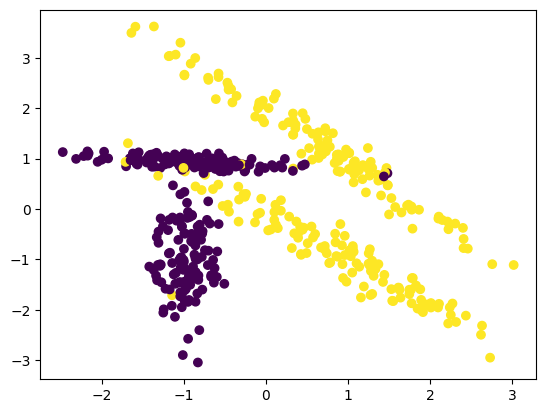

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# TODO: load and display data
X, y = np.load('X.npy'), np.load('y.npy')
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()


# Decision Trees

Decision trees are data structures, where at each level we make a decision about a feature and at the lowest level we have a decision for a class. For example, consider the following decision tree:
<div>
<img src="images/decision_tree.png" width="800"/>
</div>
You can think of a datapoint trickling down starting at the root and ending up in one of the leaf nodes that assign a class label.

That is, learning a decision tree involves learning which question to ask at which node.

## Learning

Usually we want to select questions in a way that "unmix" the labels of a dataset the best.

As an example, consider a dataset like this:

`X = [1, 2, 3, 4]`, `y = [0, 0, 1, 1]`

Here, we could ask the question: "$X\leq 1$?", which would split the dataset into 


`X1 = [1]`, `y1 = [0]` and 

`X2 = [2, 3, 4]`, `y2 = [0, 1, 1]`.

looking at the labels of the resulting datasets `y1` and `y2`, we can see that `y1` is nicely unmixed (contains only labels of one class). However `y2` is not unmixed.

A better question would be to ask: "$X\leq 2$?", in which case we would get

`X1 = [1, 2]`, `y1 = [0, 0]` and 

`X2 = [3, 4]`, `y2 = [1, 1]`.

Here both `y1` and `y2` are perfectly unmixed.

There are many ways to quantify the "unmixing" property of a dataset. For decision trees however a popular choice is the [**Gini-Impurity**](https://en.wikipedia.org/wiki/Decision_tree_learning#Gini_impurity). It measures the probability that we would missclasify a sample if we classified according to the distribution of labels.

Let $p_i$ be the relative frequency of class $i$ in the dataset with labels $y$, then the Gini-Impurity is defined as

\begin{align*}
I_G(y) = 1 - \sum_i p_i^2\,.
\end{align*}

In the following figure we can see the Gini-Impurity for binary classification problems depending on the relative frequency $p_0$ of class 0: 
<div>
<img src="images/gini.png" width="500"/>
</div>
If we have a perfectly unmixed dataset, the Gini-Impurity is 0. The maximum value is 0.5 if we have the same amount of both labels. Recall that for decision trees we want to split a dataset into subsets of low Gini-Impurity.

### Task 2

Implement the following function and calculate the Gini-Impurity for the labels of the dataset.

In [2]:
def gini_imp(y : np.ndarray) -> float:
    '''
    Calculates Gini-Impurity for binary labels.
    
    @Params:
        y... labels in {0, 1}
        
    @Returns: 
        Gini-Impurity
    '''
    # TODO: implement
    p_0 = np.mean(y == 0)
    p_1 = np.mean(y == 1)
    return 1 - (p_0**2 + p_1**2)
    

# assertions
assert np.isclose(gini_imp(y), 0.499928)

We want to use the Gini-Impurity to evaluate how good a splitting of a dataset is. For this we simply calculate a weighted sum of the impurities of the individual splits. Let $y_0, y_1$ be splits of a dataset $y$. Then we simply compute the score

\begin{align*}
S(y_0, y_1) = \cfrac{|y_0|}{|y_0| + |y_1|}I_G(y_0) + \cfrac{|y_1|}{|y_0| + |y_1|}I_G(y_1)\,.
\end{align*}

That is we weight each the individual impurities with the size of the splits.

### Task 3

Implement the following function and verify the score if we would split the dataset according to the question "$x_0 \leq 0$?".

In [3]:
def gini_imp_split(y0 : np.ndarray, y1 : np.ndarray) -> float:
    '''
    Weighted Gini-Impurity for a split into two sets of labels (binary classification).
    
    @Params:
        y0... label set
        y1... label set
    
    @Returns:
        Impurity score (lower = better)
    '''
    # TODO: implement
    n = len(y0) + len(y1)
    return (len(y0) * gini_imp(y0) + len(y1) * gini_imp(y1)) / n



# assertions
mask = X[:, 0] <= 0
y0 = y[mask]
y1 = y[~mask]
assert np.isclose(gini_imp_split(y0, y1), 0.21925534616082165)

Now the challenge is to find the index and the value that produces the lowest score ($\rightarrow$ best split).
For decision trees we do this in three steps:

1. Iterate trough all $x\in X$ and all dimensions $i$. Let $x_i = v$ be the value that we observe.
2. Score the split according to "$x_i \leq v$?".
3. Report dimension $i$ and value $v$ of best score

In practice we do not use the value $v$ but rather the average of $v$ and the first value for $x_i$ that is $> v$. 

As an example, if we identified $x_0 \leq 1.5$ as the best split, we will look for the lowest value of $x_0$ that is $>1.5$ and report the mean of those two values. Lets say this next greater value is $1.6$, then we will report index 0 and value $0.5(1.5 + 1.6) = 1.55$. This way we draw the decision boundary between the datapoints rather than on the datapoints.

### Task 4

Implement the following function that searches for the best split of a dataset.

Use this function to find the best split of our dataset.

In [4]:
def best_split(X : np.ndarray, y : np.ndarray) -> tuple:
    '''
    Identifies the best split of a dataset according to Gini-Impurity.
    
    @Params:
        X... samples
        y... labels
        
    @Returns:
        triple (index, value, Gini-Score) of split
    '''
    # TODO: implement
    best_idx, best_val, best_gi = None, None, np.inf
    for idx in range(X.shape[1]):
        for val in np.unique(X[:, idx]):
            mask = X[:, idx] <= val
            y0, y1 = y[mask], y[~mask]
            gi = gini_imp_split(y0, y1)
            if gi < best_gi:
                best_idx, best_val, best_gi = idx, val, gi

    # draw the boundary between the points: mean of v and the next greater value
    col = X[:, best_idx]
    greater = col[col > best_val]
    if greater.size > 0:
        best_val = 0.5 * (best_val + greater.min())

    return best_idx, best_val, best_gi


# assertions
idx, v, gi = best_split(X, y)

assert idx == 0
assert np.isclose(v, -0.15385073614765354)
assert np.isclose(gi, 0.19709883984704135)

/Users/mika/Developer/Uni/statistical_learning_theory_LAB/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/mika/Developer/Uni/statistical_learning_theory_LAB/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


With this functionality we have everything to recursively build up a decision tree.

Each node in the tree has the following attributes:

- `X`, `y`, `gi`: part of the dataset that is passed to the node
- `depth`, `max_depth`: depth of the node in the tree as well as the maximum depth of the tree

And can perform the following operations:

- `split`: if not already pure or at `max_depth`, finds the best split of its dataset and creates two child nodes (+1 depth)
- `predict` : given a dataset predicts labels accoding to its children (or according to its labels if we have no children)

### Task 5

Implement the following `Node` class which implements the functionality of a single node. 

Use the provided `DecisionTree` class to learn and print a decision tree with maximum depth of 2 on our dataset.

In [5]:
class Node():
        
    def __init__(self, X : np.ndarray, y : np.ndarray, depth : int, max_depth : int):
        '''
        Constructor for a node.
        
        @Params:
            X... samples
            y... labels
            depth... depth of this node in the tree
            max_depth... maximum depth of any node in the tree
        '''
        self.X = X
        self.y = y
        self.depth = depth
        self.max_depth = max_depth
        
        self.gi = gini_imp(self.y)
        self.split_idx = None
        self.split_value = None
        self.left = None
        self.right = None
        
        
        
    def split(self):
        '''
        Creates child nodes (self.left, self.right) if labels are not already pure.
        '''
        # TODO: implement
        if self.gi == 0 or self.depth >= self.max_depth:
            return 
        self.split_idx, self.split_value, _ = best_split(self.X, self.y)
        mask = self.X[:, self.split_idx] <= self.split_value
        self.left = Node(self.X[mask], self.y[mask], self.depth + 1, self.max_depth)
        self.right = Node(self.X[~mask], self.y[~mask], self.depth + 1, self.max_depth)
        self.left.split()
        self.right.split()
           
        
    def predict(self, X : np.ndarray) -> np.ndarray:
        '''
        Predicts labels for samples.
        
        @Params:
            X... samples
            
        @Returns:
            predicted labels by this node
        '''
        # TODO: implement
        if self.split_idx is None:
            return np.full(X.shape[0], round(np.mean(self.y)))   # <-- round
        mask = X[:, self.split_idx] <= self.split_value
        y_pred = np.empty(X.shape[0])
        y_pred[mask] = self.left.predict(X[mask])
        y_pred[~mask] = self.right.predict(X[~mask])
        return y_pred
            
        
    def __repr__(self) -> str:
        '''
        String representation of the node.
        
        @Returns:
            a string that represents the subtree with this node as root.
            Something like 
            x0 < 1.5?
                str(child1)
            else
                str(child2)
            
        '''
        ident_str = '\t' * self.depth 
        if self.split_idx is not None:    
            ret = f'{ident_str}x_{self.split_idx} <= {self.split_value}?\n'
            ret += str(self.left)
            ret += f'{ident_str}else:\n'
            ret += str(self.right)
            ret += '\n'
        else:
            ret = f'{ident_str}{np.mean(self.y)}\n'
        return ret


class DecisionTree():
    '''
    Provided. A wrapper class for the root of the decision tree.
    This will give you an idea of how the Node class is used.
    '''
    
    def __init__(self, max_depth : int = np.inf):
        '''
        Constructor of decision tree.
        
        @Params:
            max_depth... maximum depth of any node in the tree
        '''
        self.root = None
        self.max_depth = max_depth
        
    def fit(self, X : np.ndarray, y : np.ndarray):
        '''
        Learns the nodes of the decision tree.
        
        @Params:
            X... samples
            y... labels
        '''
        self.root = Node(X, y, 0, self.max_depth)
        self.root.split()
        
    def predict(self, X : np.ndarray) -> np.ndarray:
        '''
        Predicts labels for samples.
        
        @Params:
            X... samples
        '''
        return self.root.predict(X)
    
    def __repr__(self) -> str:
        '''
        String representation of the tree.
        '''
        return str(self.root)
    
    
# assertions
dt = DecisionTree(2)
dt.fit(X, y)

node = dt.root
assert node.split_idx == 0
assert np.isclose(node.split_value, -0.15385073614765354)

node = dt.root.left
assert node.split_idx == 1
assert np.isclose(node.split_value, 1.2240952599987902)

node = dt.root.right
assert node.split_idx == 0
assert np.isclose(node.split_value, 0.3295256957451717)


print(dt)

x_0 <= -0.15385073614765354?
	x_1 <= 1.2240952599987902?
		0.08235294117647059
	else:
		1.0

else:
	x_0 <= 0.3295256957451717?
		0.7567567567567568
	else:
		0.9783783783783784





### Task 6

Calculate the accuracy of the decision tree on the dataset and visualize the decision boundary.

You can use `utils.plot_dec_boundary` for the visualization.

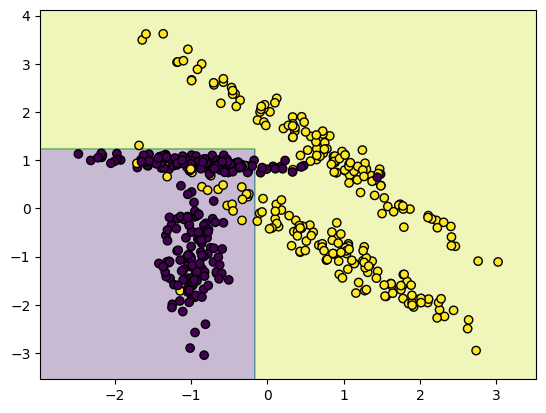

In [6]:
# TODO: accuracy
y_pred = dt.predict(X)
accuracy = np.mean(y_pred == y)
assert accuracy == 0.932


# TODO: plot decision boundary

# is utils missing?

xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
    np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = dt.predict(grid).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
plt.show()


### Task 7

Use the [scikit learn implementation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) to learn a decision tree with the same maximum depth as your tree from Task 5.

Compare the decision boundary, accuracy and the learned decision rules to those of your own implementation.

In [7]:
# use scikit learn implementation
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

# same max_depth as our own tree from Task 5
sk_tree = DecisionTreeClassifier(max_depth=2, criterion='gini', random_state=0)
sk_tree.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

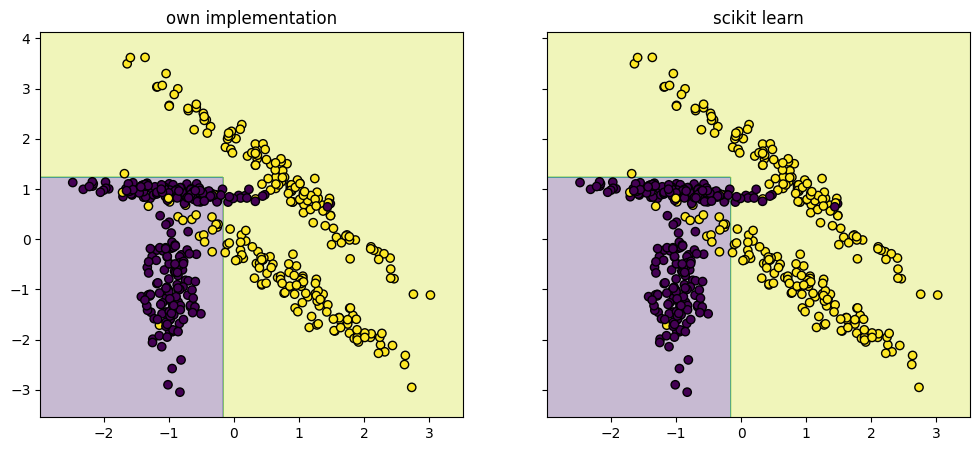

In [8]:
#TODO compare decision boundary (own tree vs. scikit learn, side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

Z_own = dt.predict(grid).reshape(xx.shape)
Z_sk = sk_tree.predict(grid).reshape(xx.shape)

for ax, Z, title in zip(axes, [Z_own, Z_sk], ['own implementation', 'scikit learn']):
    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
    ax.set_title(title)

plt.show()


In [9]:
#TODO compare accuracy
acc_own = np.mean(dt.predict(X) == y)
acc_sk = np.mean(sk_tree.predict(X) == y)

print(f'accuracy own implementation: {acc_own}')
print(f'accuracy scikit learn:       {acc_sk}')


accuracy own implementation: 0.932
accuracy scikit learn:       0.932


In [10]:
#TODO compare parameters (learned decision rules)
print('scikit learn rules:')
print(export_text(sk_tree, feature_names=['x_0', 'x_1']))

print('own implementation rules:')
print(dt)


scikit learn rules:
|--- x_0 <= -0.15
|   |--- x_1 <= 1.22
|   |   |--- class: 0
|   |--- x_1 >  1.22
|   |   |--- class: 1
|--- x_0 >  -0.15
|   |--- x_0 <= 0.33
|   |   |--- class: 1
|   |--- x_0 >  0.33
|   |   |--- class: 1

own implementation rules:
x_0 <= -0.15385073614765354?
	x_1 <= 1.2240952599987902?
		0.08235294117647059
	else:
		1.0

else:
	x_0 <= 0.3295256957451717?
		0.7567567567567568
	else:
		0.9783783783783784





## Influence of Tree depth

Now we want to investigate the influence of the maximum tree depth on the classification accuracy.

### Task 8

Split the dataset into train- and testdata and plot the train- and test accuracy for an increasing maximum tree depth.

You can use the scikit learn implementation or your own.

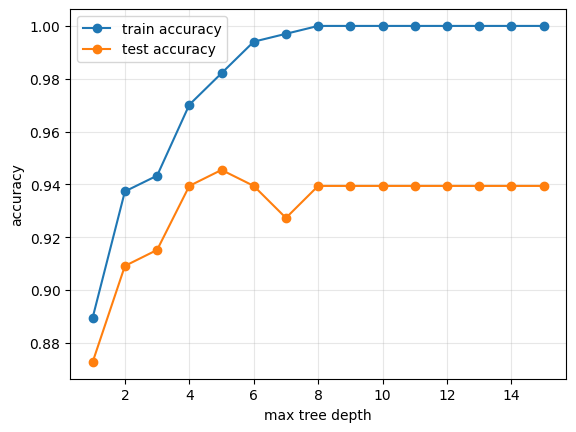

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

#TODO  plot train and test accuracy for increasing tree depth
depths = range(1, 16)
train_acc, test_acc = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, criterion='gini', random_state=0)
    clf.fit(X_train, y_train)
    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))

plt.plot(depths, train_acc, marker='o', label='train accuracy')
plt.plot(depths, test_acc, marker='o', label='test accuracy')
plt.xlabel('max tree depth')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Task 9

In your own words, describe the influence of the maximum tree depth.

The maximum tree depth controls the **model complexity** and therefore the trade-off between underfitting and overfitting (bias–variance trade-off):

- **Small depth (e.g. 1–2):** The tree can only ask very few questions and draws a coarse decision boundary. It underfits -> both train and test accuracy are low because the model is too simple to capture the structure of the data (high bias).

- **Increasing depth:** The tree can carve out finer regions, so the training accuracy keeps rising and approaches $100%$ once the leaves become (almost) pure. The test accuracy first improves as well, because the additional splits capture real structure in the data. In our experiment it reaches its optimum at around depth 5.

- **Large depth:** Beyond the optimum the training accuracy stays at $\approx100%$, but the test accuracy stagnates or even drops again. The tree now fits noise and individual outliers of the training set instead of generalizable patterns -> it overfits (low bias, high variance).

**Conclusion:** The maximum depth should be chosen as a hyperparameter (e.g. via the test/validation accuracy). It must be large enough to capture the underlying structure, but small enough to avoid memorizing the training data. The gap between train and test accuracy is a direct indicator of overfitting.